<a href="https://colab.research.google.com/github/samridhi-p/WebDev/blob/main/WineQualityPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

red = pd.read_csv('winequality-red.csv', sep =';')
white = pd.read_csv('winequality-white.csv', sep=';')

In [ ]:
red['type'] = 'red'
white['type']= 'white'


Addding type column in both red and white wine file

In [ ]:
df = pd.concat([red,white], axis =0, ignore_index=True)

Combined both the flies at axis =0, meaning they are added row wise like on top of eeachother

In [ ]:
type_dummies = pd.get_dummies(df['type'], drop_first=True)

In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['type'].value_counts())

(6497, 13)
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64
type
white    4898
red      1599
Name: count, dtype: int64


In [ ]:
df['quality'].value_counts().sort_index()

,count
quality,
3,30
4,216
5,2138
6,2836
7,1079
8,193
9,5


this shows that data is really concentrated at 5,6 & 7. It constitutes 93% of the entire data

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
df.corr(numeric_only=True)['quality'].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.444319
citric acid,0.085532
free sulfur dioxide,0.055463
sulphates,0.038485
pH,0.019506
residual sugar,-0.036980
total sulfur dioxide,-0.041385
fixed acidity,-0.076743
chlorides,-0.200666


It computes correlation between all numeric columns. ['quality'] isolates the correlation values specifically between the target variable 'quality' and every other numeric feature.

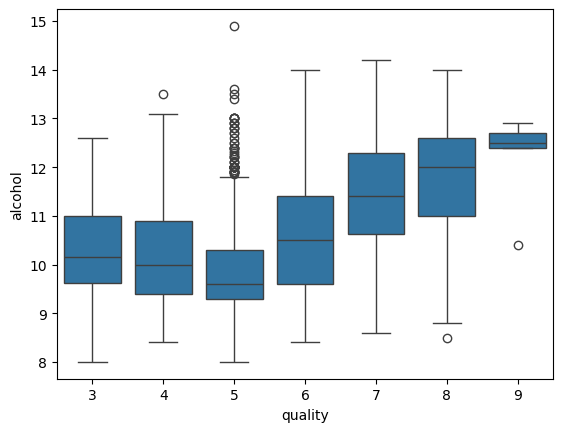

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df, x='quality',y='alcohol')
plt.show()

It confirsms clean upward trend from 5 to 9 but 3/4 breaks the pattern

In [ ]:
df['quality_binary']=df['quality'].apply(lambda x: 1 if x >=7 else 0 )

since the data is concentrated at 5,6 and 7, we can't use 7-class classifiication, so instead we opt for  binary class classification, which can only tell if the alcohol is good or bad.

In [ ]:
df['quality_binary'].value_counts()

,count
quality_binary,
0,5220
1,1277


if the quality is greated than or equal to 7 its good or else its bad.

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(['quality', 'quality_binary','type'], axis =1)
X = pd.concat([X, type_dummies], axis=1)
y = df['quality_binary']
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size = 0.2, random_state=42, stratify = y)

Stratified, preserved 80/20 class ratio

In [ ]:
print (X_train.shape, X_test.shape,y_train.shape,y_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(5197, 12) (1300, 12) (5197,) (1300,)
quality_binary
0    4176
1    1021
Name: count, dtype: int64
quality_binary
0    1044
1     256
Name: count, dtype: int64


Modifying the data so all the features share a common scale

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

FInally doing the actual taining. The model looks at the acaled training features and their true laels and adjusts internal weights to find the pattern that best separates "good" from "not good" wines

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, classification_report

print ("Accuracy: ", accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print (classification_report(y_test, y_pred))

Accuracy:  0.8223076923076923
[[1002   42]
 [ 189   67]]
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1044
           1       0.61      0.26      0.37       256

    accuracy                           0.82      1300
   macro avg       0.73      0.61      0.63      1300
weighted avg       0.80      0.82      0.79      1300



In [ ]:
model_balanced = LogisticRegression(class_weight ='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.7123076923076923
[[734 310]
 [ 64 192]]
              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1044
           1       0.38      0.75      0.51       256

    accuracy                           0.71      1300
   macro avg       0.65      0.73      0.65      1300
weighted avg       0.81      0.71      0.74      1300



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print ("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy:  0.8892307692307693
[[1013   31]
 [ 113  143]]
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1044
           1       0.82      0.56      0.67       256

    accuracy                           0.89      1300
   macro avg       0.86      0.76      0.80      1300
weighted avg       0.88      0.89      0.88      1300



In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False))

alcohol                 0.159672
density                 0.115262
volatile acidity        0.089993
chlorides               0.087107
residual sugar          0.084228
sulphates               0.082275
total sulfur dioxide    0.081782
pH                      0.079104
free sulfur dioxide     0.077383
citric acid             0.074065
fixed acidity           0.066215
white                   0.002913
dtype: float64


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.8469230769230769
[[999  45]
 [154 102]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1044
           1       0.69      0.40      0.51       256

    accuracy                           0.85      1300
   macro avg       0.78      0.68      0.71      1300
weighted avg       0.83      0.85      0.83      1300

